In [8]:
# -------------------------------------------------------------------------
# Ejemplo de uso de Tidyverse con Breast Cancer Data
# -------------------------------------------------------------------------

# 1. Cargar el ecosistema tidyverse
# Esto carga dplyr, ggplot2, readr, tidyr, purrr, stringr, etc.
if (!require("tidyverse")) install.packages("tidyverse")
library(tidyverse)

# 2. Lectura de datos con 'readr'
# read_csv es más rápido que read.csv y genera un 'tibble' (data frame optimizado)
cancer_data <- read_csv("../../data/breast_cancer_data.csv")

Rows: 569 Columns: 31
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (31): mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, mean concavity, mean conc...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
# 3. Manipulación de datos con 'dplyr'
# Vamos a limpiar y transformar los datos en un solo flujo (pipeline)
cancer_cleaned <- cancer_data %>%
  # Seleccionar solo algunas columnas relevantes para el ejemplo
  select(`mean radius`, `mean texture`, `mean area`, target) %>%
  # Filtrar filas (ejemplo: solo áreas mayores a 500)
  filter(`mean area` > 500) %>%
  # Crear o transformar columnas con mutate
  mutate(
    # Convertir target a etiqueta descriptiva
    diagnosis = if_else(target == 0, "Maligno", "Benigno"),
    # Calcular el ratio entre radio y textura
    radius_texture_ratio = `mean radius` / `mean texture`
  ) %>%
  # Ordenar por área de forma descendente
  arrange(desc(`mean area`))

In [10]:
# 4. Resumen y Agrupación (Group by & Summarize)
# Calcular promedios por tipo de diagnóstico
summary_stats <- cancer_cleaned %>%
  group_by(diagnosis) %>%
  summarize(
    count = n(),
    avg_radius = mean(`mean radius`),
    avg_area = mean(`mean area`),
    max_area = max(`mean area`)
  )

print("Estadísticas resumidas por diagnóstico:")
print(summary_stats)

[1] "Estadísticas resumidas por diagnóstico:"
# A tibble: 2 × 5
  diagnosis count avg_radius avg_area max_area
  <chr>     <int>      <dbl>    <dbl>    <dbl>
1 Benigno     137       13.9     597.     992.
2 Maligno     202       17.7    1005.    2501 


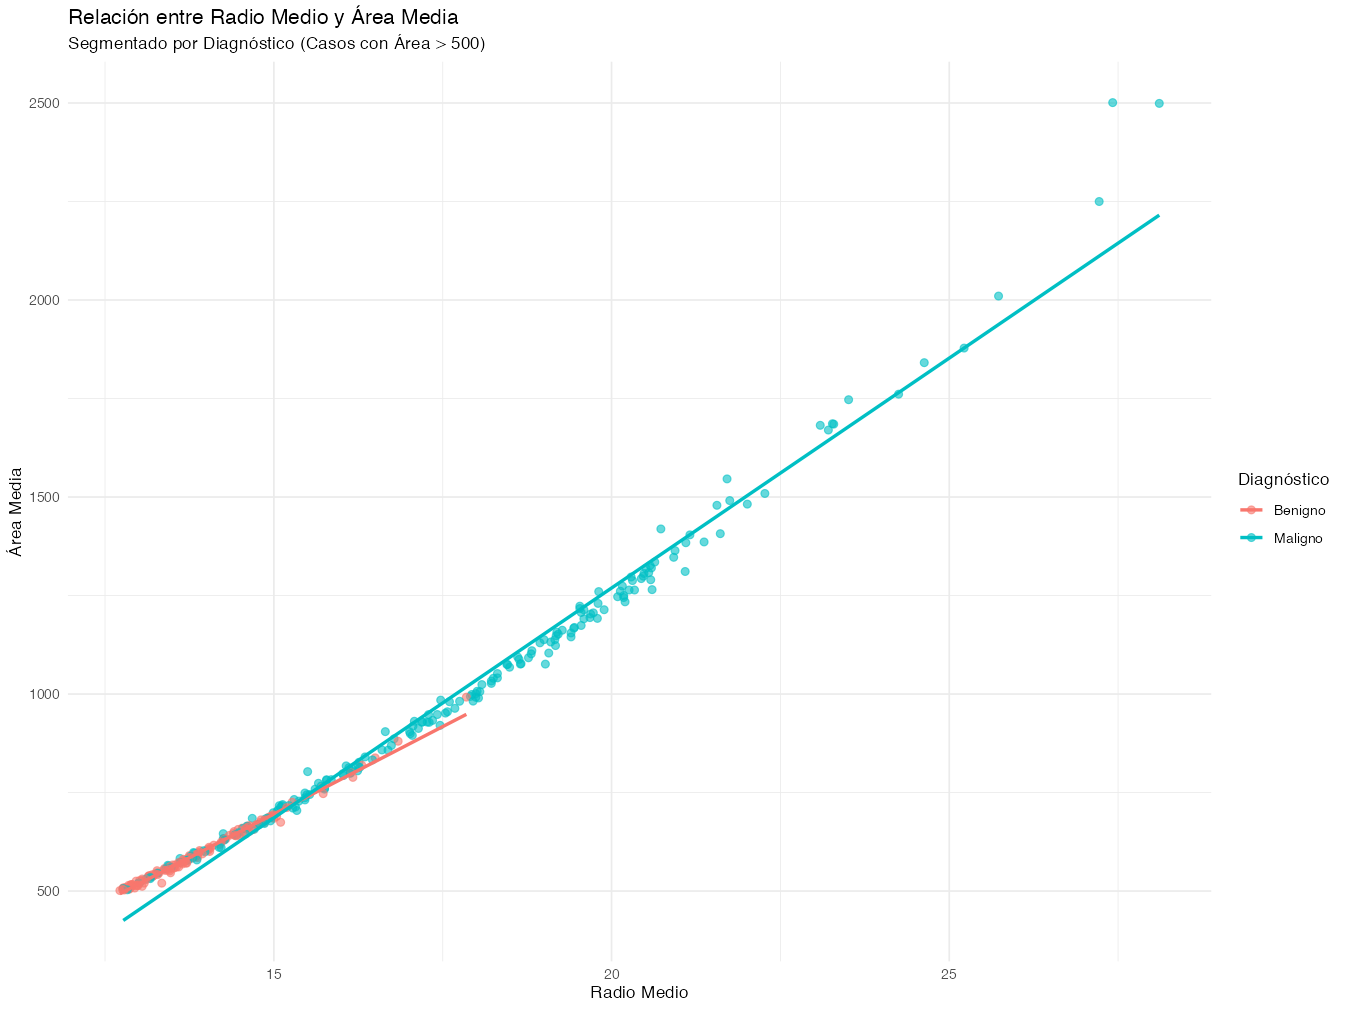

`geom_smooth()` using formula = 'y ~ x'

In [11]:
# 5. Visualización con 'ggplot2'
# Creación de un gráfico de dispersión (Scatter Plot)
ggplot(cancer_cleaned, aes(x = `mean radius`, y = `mean area`, color = diagnosis)) +
  geom_point(alpha = 0.6, size = 2) +
  # Añadir una línea de tendencia suavizada
  geom_smooth(method = "lm", se = FALSE) +
  # Personalización de etiquetas y tema
  labs(
    title = "Relación entre Radio Medio y Área Media",
    subtitle = "Segmentado por Diagnóstico (Casos con Área > 500)",
    x = "Radio Medio",
    y = "Área Media",
    color = "Diagnóstico"
  ) +
  theme_minimal()

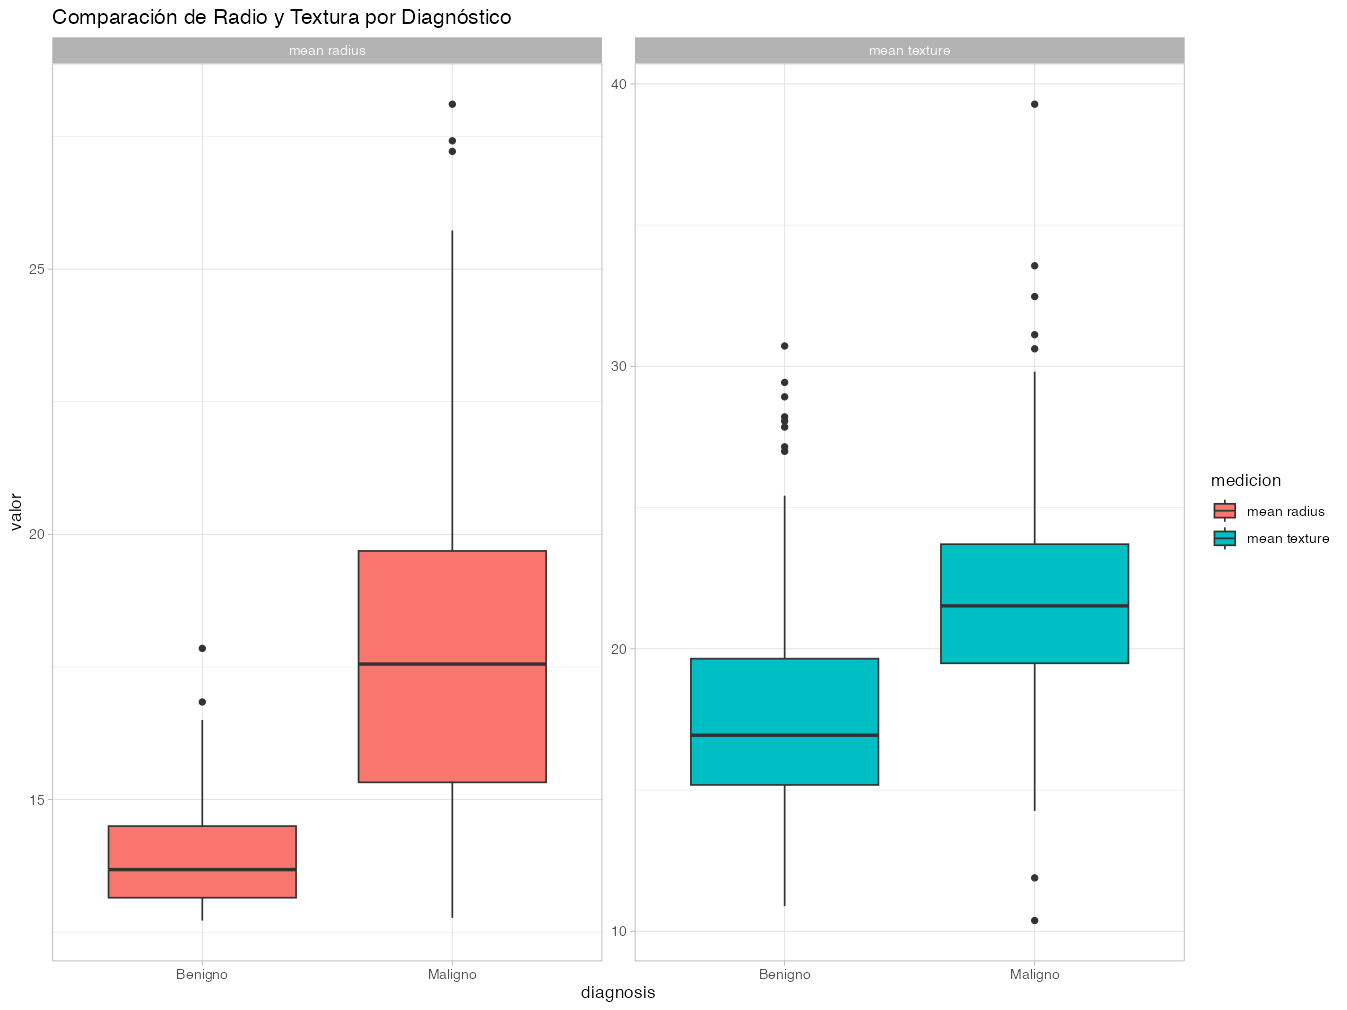

In [12]:
# 6. Ejemplo de 'tidyr' (Pivotar datos)
# Útil cuando necesitas preparar datos para visualizaciones complejas
data_long <- cancer_cleaned %>%
  select(diagnosis, `mean radius`, `mean texture`) %>%
  pivot_longer(
    cols = starts_with("mean"), 
    names_to = "medicion", 
    values_to = "valor"
  )

# Visualizar la distribución de ambas métricas tras pivotar
ggplot(data_long, aes(x = diagnosis, y = valor, fill = medicion)) +
  geom_boxplot() +
  facet_wrap(~medicion, scales = "free") +
  labs(title = "Comparación de Radio y Textura por Diagnóstico") +
  theme_light()